In [1]:
#Libraries used
import numpy as np
from matplotlib import pyplot as plt
from numpy.lib import stride_tricks
import os
import pandas as pd
import scipy.io.wavfile as wav
import torch
import gc
import shutil
from sklearn.model_selection import train_test_split
import cv2
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [2]:
#Clear memory
gc.collect()
torch.cuda.empty_cache()

In [3]:
base_dir = "dog_audio_dataset_original"
audio_files = []
class_names = []
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)    
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.endswith(('.wav', '.mp3')):
                audio_files.append(file)
                class_names.append(class_name)
df = pd.DataFrame({"Audio_Filename": audio_files, "Class_Name": class_names})

In [4]:
df

,Audio_Filename,Class_Name
0,dog_0.wav,bark
1,dog_1.wav,bark
2,dog_10.wav,bark
3,dog_11.wav,bark
4,dog_12.wav,bark
...,...,...
108,dog44.wav,grunt
109,Dog5.wav,grunt
110,Dog50.wav,grunt
111,Dog52.wav,grunt


In [5]:
df['Class_Name'].value_counts()

Class_Name
bark     46
grunt    34
growl    33
Name: count, dtype: int64

In [6]:
audio_base_path = r"dog_audio_dataset_original"
output_base_path = r"dog_audio_dataset_original_spectrograms"

In [7]:
#Converting audio files into spectrograms
def fourier_transformation(sig, frameSize, overlapFac=0.5, window=np.hanning):
    win = window(frameSize)
    hopSize = int(frameSize - np.floor(overlapFac * frameSize))

    samples = np.append(np.zeros(int(np.floor(frameSize / 2.0))), sig)
    cols = np.ceil((len(samples) - frameSize) / float(hopSize)) + 1
    samples = np.append(samples, np.zeros(frameSize))

    frames = np.lib.stride_tricks.as_strided(
        samples, shape=(int(cols), frameSize),
        strides=(samples.strides[0] * hopSize, samples.strides[0])
    ).copy()

    frames *= win
    return np.fft.rfft(frames)

def make_logscale(spec, sr=44100, factor=20.):
    timebins, freqbins = np.shape(spec)
    scale = np.linspace(0, 1, freqbins) ** factor
    scale *= (freqbins - 1) / max(scale)
    scale = np.unique(np.round(scale))

    newspec = np.complex128(np.zeros([timebins, len(scale)]))
    for i in range(len(scale)):
        if i == len(scale) - 1:
            newspec[:, i] = np.sum(spec[:, int(scale[i]):], axis=1)
        else:
            newspec[:, i] = np.sum(spec[:, int(scale[i]):int(scale[i + 1])], axis=1)

    allfreqs = np.abs(np.fft.fftfreq(freqbins * 2, 1. / sr)[:freqbins + 1])
    freqs = [np.mean(allfreqs[int(scale[i]):int(scale[i + 1])]) if i < len(scale) - 1 else np.mean(allfreqs[int(scale[i]):]) for i in range(len(scale))]

    return newspec, freqs

def plot_spectrogram(location, categorie, output_folder, binsize=2**10, colormap="jet"):
    try:
        samplerate, samples = wav.read(location)
    except FileNotFoundError:
        print(f"Error: File not found -> {location}")
        return
    s = fourier_transformation(samples, binsize)
    sshow, freq = make_logscale(s, factor=1.0, sr=samplerate)
    ims = 20. * np.log10(np.abs(sshow) / 10e-6)
    timebins, freqbins = np.shape(ims)
    print(f"Processing {categorie}: {location}")
    plt.figure(figsize=(15, 7.5))
    plt.title(f'Class Label: {categorie}')
    plt.imshow(np.transpose(ims), origin="lower", aspect="auto", cmap=colormap, interpolation="none")
    plt.colorbar()
    plt.xlabel("time (s)")
    plt.ylabel("frequency (hz)")
    plt.xlim([0, timebins - 1])
    plt.ylim([0, freqbins])
    os.makedirs(output_folder, exist_ok=True)
    filename = os.path.basename(location).replace('.wav', '.png')
    save_path = os.path.join(output_folder, filename)
    plt.savefig(save_path, bbox_inches="tight")
    plt.close()
    print(f"Saved spectrogram: {save_path}")
for class_name in os.listdir(audio_base_path):
    class_path = os.path.join(audio_base_path, class_name)
    if os.path.isdir(class_path):
        output_folder = os.path.join(output_base_path, class_name)
        for filename in os.listdir(class_path):
            if filename.endswith(".wav"):
                audio_file_path = os.path.join(class_path, filename)
                plot_spectrogram(audio_file_path, class_name, output_folder)


Processing bark: dog_audio_dataset_original\bark\dog_0.wav
Saved spectrogram: dog_audio_dataset_original_spectrograms\bark\dog_0.png
Processing bark: dog_audio_dataset_original\bark\dog_1.wav


C:\Windows\Temp\ipykernel_13276\4173535936.py:43: RuntimeWarning: divide by zero encountered in log10
  ims = 20. * np.log10(np.abs(sshow) / 10e-6)


Saved spectrogram: dog_audio_dataset_original_spectrograms\bark\dog_1.png
Processing bark: dog_audio_dataset_original\bark\dog_10.wav
Saved spectrogram: dog_audio_dataset_original_spectrograms\bark\dog_10.png
Processing bark: dog_audio_dataset_original\bark\dog_11.wav
Saved spectrogram: dog_audio_dataset_original_spectrograms\bark\dog_11.png
Processing bark: dog_audio_dataset_original\bark\dog_12.wav
Saved spectrogram: dog_audio_dataset_original_spectrograms\bark\dog_12.png
Processing bark: dog_audio_dataset_original\bark\dog_13.wav
Saved spectrogram: dog_audio_dataset_original_spectrograms\bark\dog_13.png
Processing bark: dog_audio_dataset_original\bark\dog_14.wav
Saved spectrogram: dog_audio_dataset_original_spectrograms\bark\dog_14.png
Processing bark: dog_audio_dataset_original\bark\dog_15.wav
Saved spectrogram: dog_audio_dataset_original_spectrograms\bark\dog_15.png
Processing bark: dog_audio_dataset_original\bark\dog_16.wav
Saved spectrogram: dog_audio_dataset_original_spectrogra

In [8]:
spectrogram_base_path = r"dog_audio_dataset_original_spectrograms"
spectrogram_data = []
for category in os.listdir(spectrogram_base_path):
    category_path = os.path.join(spectrogram_base_path, category)
    if os.path.isdir(category_path):
        for filename in os.listdir(category_path):
            if filename.endswith(".png"):
                spectrogram_data.append({"Filename": filename, "Category": category})
specto_df = pd.DataFrame(spectrogram_data)

In [9]:
specto_df

,Filename,Category
0,dog_0.png,bark
1,dog_1.png,bark
2,dog_10.png,bark
3,dog_11.png,bark
4,dog_12.png,bark
...,...,...
108,dog44.png,grunt
109,Dog5.png,grunt
110,Dog50.png,grunt
111,Dog52.png,grunt


In [10]:
spectrogram_base_path = r"dog_audio_dataset_original_spectrograms"
yolo_output_path = r"dog_audio_dataset_original_spectrograms_in_yolo_format"
train_path = os.path.join(yolo_output_path, "train")
val_path = os.path.join(yolo_output_path, "val")
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
specto_df = specto_df
train_df, val_df = train_test_split(specto_df, test_size=0.2, random_state=42, stratify=specto_df["Category"])
def copy_spectrograms(df, output_folder):
    for _, row in df.iterrows():
        filename, category = row["Filename"], row["Category"]
        src_path = os.path.join(spectrogram_base_path, category, filename)
        category_folder = os.path.join(output_folder, category)
        os.makedirs(category_folder, exist_ok=True)
        dest_path = os.path.join(category_folder, filename)
        shutil.copy(src_path, dest_path)
copy_spectrograms(train_df, train_path)
copy_spectrograms(val_df, val_path)
print("✅ YOLO Dataset Created Successfully!")
print(f"📂 Train images: {len(train_df)}")
print(f"📂 Validation images: {len(val_df)}")

✅ YOLO Dataset Created Successfully!
📂 Train images: 90
📂 Validation images: 23


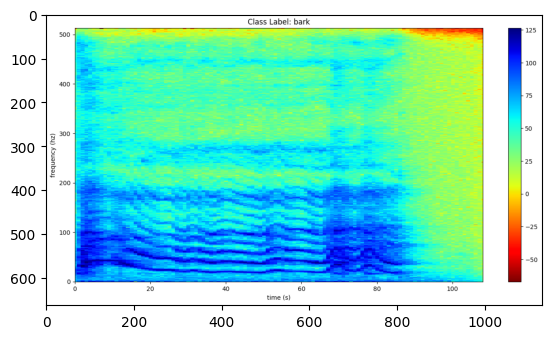

In [16]:
#Sample bark spectorgram from training set
img=cv2.imread(r"dog_audio_dataset_original_spectrograms_in_yolo_format\train\bark\dog_0.png")
plt.imshow(img,cmap='jet')

In [12]:
img.shape

(663, 1131, 3)

In [19]:
#Code for predicting class with unseen data
def test_vis(location, filepath, binsize=2**10, colormap="jet"):
    samplerate, samples = wav.read(location)
    s = fourier_transformation(samples, binsize)
    sshow, freq = make_logscale(s, factor=1.0, sr=samplerate)
    with np.errstate(divide='ignore'):
        ims = 20.*np.log10(np.abs(sshow)/10e-6) # amplitude to decibel
    timebins, freqbins = np.shape(ims)
    plt.figure(figsize=(15, 7.5))
    plt.imshow(np.transpose(ims), origin="lower", aspect="auto", cmap=colormap, interpolation="none")
    plt.axis('off')
    plt.xlim([0, timebins-1])
    plt.ylim([0, freqbins])
    plt.savefig(filepath, bbox_inches="tight")
    plt.close()
    return

In [20]:
#Unseen data filepath
file=r'sample_audio_files\dog_barking_71.wav'
filename = os.path.splitext(os.path.basename(file))[0]

In [ ]:
#conversion of unseen data into a spectrogram
test_vis(file, filepath=f'sample_audio_files_spectrograms\{filename}.jpg')

In [23]:
#loading YOLO V* image classification model
model = YOLO('yolov8n-cls.pt')

In [ ]:
#training of Audio-based dog emotion classifier for 50 epochs
#results = model.train(data=r'dog_audio_dataset_original_spectrograms_in_yolo_format', epochs=50, imgsz=640)

New https://pypi.org/project/ultralytics/8.3.82 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.75  Python-3.11.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=classify, mode=train, model=yolov8n-cls.pt, data=C:\Users\sujay\Desktop\project_2\YOLO_Dataset, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train7, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_m

train: Scanning C:\Users\sujay\Desktop\project_2\YOLO_Dataset\train... 90 images, 0 corrupt: 100%|██████████| 90/90 [00:00<?, ?it/s]
val: Scanning C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val... 23 images, 0 corrupt: 100%|██████████| 23/23 [00:00<?, ?it/s]


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\classify\train7
Starting training for 50 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00,  1.13it/s]

                   all      0.304          1


...

      50/50      1.51G    0.08493         10        640: 100%|██████████| 6/6 [00:00<00:00,  9.33it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00, 15.24it/s]

                   all      0.913          1



50 epochs completed in 0.035 hours.
Optimizer stripped from runs\classify\train7\weights\last.pt, 3.0MB
Optimizer stripped from runs\classify\train7\weights\best.pt, 3.0MB

Validating runs\classify\train7\weights\best.pt...
Ultralytics 8.3.75  Python-3.11.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 73 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: C:\Users\sujay\Desktop\project_2\YOLO_Dataset\train... found 90 images in 3 classes  
val: C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val... found 23 images in 3 classes  
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00, 12.62it/s]


                   all          1          1
Speed: 1.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train7


In [ ]:
#Evaluaution metrics audio-based dog emotion classifier for 50 epochs
#model_path = r"runs\classify\train7\weights\best.pt"
#model = YOLO(model_path)
#class_labels = {0: 'bark', 1: 'growl', 2: 'grunt'}
#test_dir = r"dog_audio_dataset_original_spectrograms_in_yolo_format\val"
#y_true = []
#y_pred = []
#for class_name in class_labels.values():
#    class_path = os.path.join(test_dir, class_name)
#    if not os.path.exists(class_path):
#        continue
#    for filename in os.listdir(class_path):
#        if filename.endswith(('.jpg', '.png')):  
#            y_true.append(class_name)  
#            img_path = os.path.join(class_path, filename)
#            results = model(img_path)
#            predicted_index = results[0].probs.top1  
#            predicted_label = class_labels[predicted_index]              
#            y_pred.append(predicted_label)
#y_true = np.array(y_true)
#y_pred = np.array(y_pred)
#accuracy = accuracy_score(y_true, y_pred)
#precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=1)
#print(f"Accuracy: {accuracy:.4f}")
#print(f"Precision: {precision:.4f}")
#print(f"Recall: {recall:.4f}")
#print(f"F1 Score: {f1:.4f}")


image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_15.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 61.9ms
Speed: 19.0ms preprocess, 61.9ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_21.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 57.3ms
Speed: 17.1ms preprocess, 57.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_25.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 4.7ms
Speed: 13.7ms preprocess, 4.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_27.png: 640x640 bark 1.00, grunt 0.00, growl 0.00, 4.3ms
Speed: 14.4ms preprocess, 4.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_29.png: 640x640 bark 1.00, gro

In [26]:
#predciton using model trained for 50 epochs
model=YOLO(r'runs\classify\train7\weights\best.pt')
pred = model(r'sample_audio_files_spectrograms\dog_barking_71.jpg')#,save=True)
print(pred[0].names)
print(pred[0].probs)


image 1/1 c:\Users\sujay\Desktop\project_2\sample_audio_files_spectrograms\dog_barking_71.jpg: 640x640 grunt 1.00, bark 0.00, growl 0.00, 76.0ms
Speed: 26.3ms preprocess, 76.0ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)
{0: 'bark', 1: 'growl', 2: 'grunt'}
ultralytics.engine.results.Probs object with attributes:

data: tensor([2.3367e-03, 2.3180e-05, 9.9764e-01], device='cuda:0')
orig_shape: None
shape: torch.Size([3])
top1: 2
top1conf: tensor(0.9976, device='cuda:0')
top5: [2, 0, 1]
top5conf: tensor([9.9764e-01, 2.3367e-03, 2.3180e-05], device='cuda:0')


In [ ]:
#Training the audio-based dog emotion classifier for 100 epochs
#results = model.train(data=r'dog_audio_dataset_original_spectrograms_in_yolo_format', epochs=100, imgsz=640)

New https://pypi.org/project/ultralytics/8.3.82 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.75  Python-3.11.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=classify, mode=train, model=C:\Users\sujay\Desktop\project_2\runs\classify\train7\weights\best.pt, data=C:\Users\sujay\Desktop\project_2\YOLO_Dataset, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, a

train: Scanning C:\Users\sujay\Desktop\project_2\YOLO_Dataset\train... 90 images, 0 corrupt: 100%|██████████| 90/90 [00:00<?, ?it/s]
val: Scanning C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val... 23 images, 0 corrupt: 100%|██████████| 23/23 [00:00<?, ?it/s]


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\classify\train9
Starting training for 100 epochs...

      Epoch    GPU_mem       loss  Instances       Size


      1/100      1.63G     0.2581         10        640: 100%|██████████| 6/6 [00:29<00:00,  4.92s/it]
               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00,  3.37it/s]

                   all      0.696          1


...

    100/100      1.62G    0.01646         10        640: 100%|██████████| 6/6 [00:00<00:00,  7.95it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00,  9.18it/s]

                   all      0.957          1



100 epochs completed in 0.074 hours.
Optimizer stripped from runs\classify\train9\weights\last.pt, 3.0MB
Optimizer stripped from runs\classify\train9\weights\best.pt, 3.0MB

Validating runs\classify\train9\weights\best.pt...
Ultralytics 8.3.75  Python-3.11.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 73 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: C:\Users\sujay\Desktop\project_2\YOLO_Dataset\train... found 90 images in 3 classes  
val: C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val... found 23 images in 3 classes  
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00,  3.83it/s]


                   all      0.957          1
Speed: 1.2ms preprocess, 1.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train9


In [ ]:
#Evaluation Metrics of audio-based dog emotion classifier for 100 epochs
#model_path = r"runs\classify\train9\weights\best.pt"
#model = YOLO(model_path)
#class_labels = {0: 'bark', 1: 'growl', 2: 'grunt'}
#test_dir = r"dog_audio_dataset_original_spectrograms_in_yolo_format\val"
#y_true = []
#y_pred = []
#for class_name in class_labels.values():
#    class_path = os.path.join(test_dir, class_name)
#    if not os.path.exists(class_path):
#        continue
#    for filename in os.listdir(class_path):
#        if filename.endswith(('.jpg', '.png')):  
#            y_true.append(class_name)  
#            img_path = os.path.join(class_path, filename)
#            results = model(img_path)
#            predicted_index = results[0].probs.top1  
#            predicted_label = class_labels[predicted_index]              
#            y_pred.append(predicted_label)
#y_true = np.array(y_true)
#y_pred = np.array(y_pred)
#accuracy = accuracy_score(y_true, y_pred)
#precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=1)
#print(f"Accuracy: {accuracy:.4f}")
#print(f"Precision: {precision:.4f}")
#print(f"Recall: {recall:.4f}")
#print(f"F1 Score: {f1:.4f}")


image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_15.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 90.2ms
Speed: 30.9ms preprocess, 90.2ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_21.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 5.5ms
Speed: 18.4ms preprocess, 5.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_25.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 4.6ms
Speed: 17.4ms preprocess, 4.6ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_27.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 5.8ms
Speed: 17.0ms preprocess, 5.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_29.png: 640x640 bark 1.00, growl

In [ ]:
#predciton using model trained for 100 epochs
model=YOLO(r'runs\classify\train9\weights\best.pt')
pred = model(r'sample_audio_files_spectrograms\dog_barking_71.jpg')#,save=True)
print(pred[0].names)
print(pred[0].probs)


image 1/1 C:\Users\sujay\Desktop\project_2\testingspectogram\sample.jpg: 640x640 grunt 0.99, growl 0.01, bark 0.00, 21.4ms
Speed: 20.1ms preprocess, 21.4ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)
{0: 'bark', 1: 'growl', 2: 'grunt'}
ultralytics.engine.results.Probs object with attributes:

data: tensor([2.9632e-07, 9.1604e-03, 9.9084e-01], device='cuda:0')
orig_shape: None
shape: torch.Size([3])
top1: 2
top1conf: tensor(0.9908, device='cuda:0')
top5: [2, 1, 0]
top5conf: tensor([9.9084e-01, 9.1604e-03, 2.9632e-07], device='cuda:0')


In [ ]:
#Training the audio-based dog emotion classifier for 150 epochs
#results = model.train(data=r'dog_audio_dataset_original_spectrograms_in_yolo_format', epochs=150, imgsz=640)

New https://pypi.org/project/ultralytics/8.3.82 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.75  Python-3.11.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=classify, mode=train, model=yolov8n-cls.pt, data=C:\Users\sujay\Desktop\project_2\YOLO_Dataset, epochs=150, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train11, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina

train: Scanning C:\Users\sujay\Desktop\project_2\YOLO_Dataset\train... 90 images, 0 corrupt: 100%|██████████| 90/90 [00:00<?, ?it/s]
val: Scanning C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val... 23 images, 0 corrupt: 100%|██████████| 23/23 [00:00<?, ?it/s]


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\classify\train11
Starting training for 150 epochs...

      Epoch    GPU_mem       loss  Instances       Size


      1/150      1.61G      1.046         10        640: 100%|██████████| 6/6 [00:15<00:00,  2.51s/it]
               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]

                   all      0.304          1


...

    111/150      1.51G    0.04975         10        640: 100%|██████████| 6/6 [00:00<00:00,  9.80it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00, 15.59it/s]

                   all          1          1
EarlyStopping: Training stopped early as no improvement observed in last 100 epochs. Best results observed at epoch 11, best model saved as best.pt.
To update EarlyStopping(patience=100) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



111 epochs completed in 0.056 hours.
Optimizer stripped from runs\classify\train11\weights\last.pt, 3.0MB
Optimizer stripped from runs\classify\train11\weights\best.pt, 3.0MB

Validating runs\classify\train11\weights\best.pt...
Ultralytics 8.3.75  Python-3.11.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 73 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: C:\Users\sujay\Desktop\project_2\YOLO_Dataset\train... found 90 images in 3 classes  
val: C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val... found 23 images in 3 classes  
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00, 13.24it/s]


                   all          1          1
Speed: 1.0ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train11


In [ ]:
#Evalaution metrics for audio-based dog emotion classifier for 150 epochs
#model_path = r"C:\Users\sujay\Desktop\project_2\runs\classify\train11\weights\best.pt"
#model = YOLO(model_path)
#class_labels = {0: 'bark', 1: 'growl', 2: 'grunt'}
#test_dir = r"dog_audio_dataset_original_spectrograms_in_yolo_format\val"
#y_true = []
#y_pred = []
#for class_name in class_labels.values():
#    class_path = os.path.join(test_dir, class_name)
#    if not os.path.exists(class_path):
#        continue
#    for filename in os.listdir(class_path):
#        if filename.endswith(('.jpg', '.png')):  
#            y_true.append(class_name)  
#            img_path = os.path.join(class_path, filename)
#            results = model(img_path)
#            predicted_index = results[0].probs.top1  
#            predicted_label = class_labels[predicted_index]              
#            y_pred.append(predicted_label)
#y_true = np.array(y_true)
#y_pred = np.array(y_pred)
#accuracy = accuracy_score(y_true, y_pred)
#precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=1)
#print(f"Accuracy: {accuracy:.4f}")
#print(f"Precision: {precision:.4f}")
#print(f"Recall: {recall:.4f}")
#print(f"F1 Score: {f1:.4f}")


image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_15.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 22.9ms
Speed: 16.1ms preprocess, 22.9ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_21.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 22.8ms
Speed: 15.1ms preprocess, 22.8ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_25.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 21.3ms
Speed: 18.6ms preprocess, 21.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_27.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 18.7ms
Speed: 14.8ms preprocess, 18.7ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_29.png: 640x640 bark 1.00,

In [ ]:
#predciton using model trained for 150 epochs
model=YOLO(r'runs\classify\train11\weights\best.pt')
pred = model(r'sample_audio_files_spectrograms\dog_barking_71.jpg')#,save=True)
print(pred[0].names)
print(pred[0].probs)


image 1/1 c:\Users\sujay\Desktop\project_2\sample_audio_files_spectrograms\dog_barking_71.jpg: 640x640 grunt 1.00, bark 0.00, growl 0.00, 67.3ms
Speed: 34.1ms preprocess, 67.3ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
{0: 'bark', 1: 'growl', 2: 'grunt'}
ultralytics.engine.results.Probs object with attributes:

data: tensor([1.6848e-03, 1.1701e-07, 9.9832e-01], device='cuda:0')
orig_shape: None
shape: torch.Size([3])
top1: 2
top1conf: tensor(0.9983, device='cuda:0')
top5: [2, 0, 1]
top5conf: tensor([9.9832e-01, 1.6848e-03, 1.1701e-07], device='cuda:0')


In [ ]:
#Training the audio-based dog emotion classifier for 200 epochs
#results = model.train(data=r'dog_audio_dataset_original_spectrograms_in_yolo_format', epochs=200, imgsz=640)

New https://pypi.org/project/ultralytics/8.3.82 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.75  Python-3.11.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=classify, mode=train, model=C:\Users\sujay\Desktop\project_2\runs\classify\train11\weights\best.pt, data=C:\Users\sujay\Desktop\project_2\YOLO_Dataset, epochs=200, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False,

train: Scanning C:\Users\sujay\Desktop\project_2\YOLO_Dataset\train... 90 images, 0 corrupt: 100%|██████████| 90/90 [00:00<?, ?it/s]
val: Scanning C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val... 23 images, 0 corrupt: 100%|██████████| 23/23 [00:00<?, ?it/s]


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\classify\train12
Starting training for 200 epochs...

      Epoch    GPU_mem       loss  Instances       Size


      1/200       1.6G     0.5128         10        640: 100%|██████████| 6/6 [00:22<00:00,  3.82s/it]
               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00,  3.55it/s]

                   all      0.391          1


...

    112/200      1.52G    0.07312         10        640: 100%|██████████| 6/6 [00:00<00:00,  9.26it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00, 15.47it/s]

                   all      0.957          1
EarlyStopping: Training stopped early as no improvement observed in last 100 epochs. Best results observed at epoch 12, best model saved as best.pt.
To update EarlyStopping(patience=100) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



112 epochs completed in 0.052 hours.
Optimizer stripped from runs\classify\train12\weights\last.pt, 3.0MB
Optimizer stripped from runs\classify\train12\weights\best.pt, 3.0MB

Validating runs\classify\train12\weights\best.pt...
Ultralytics 8.3.75  Python-3.11.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 73 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: C:\Users\sujay\Desktop\project_2\YOLO_Dataset\train... found 90 images in 3 classes  
val: C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val... found 23 images in 3 classes  
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 1/1 [00:00<00:00, 15.19it/s]


                   all      0.957          1
Speed: 1.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train12


In [ ]:
#Evalaution metrics for audio-based dog emotion classifier for 200 epochs
#model_path = r"C:\Users\sujay\Desktop\project_2\runs\classify\train12\weights\best.pt"
#model = YOLO(model_path)
#class_labels = {0: 'bark', 1: 'growl', 2: 'grunt'}
#test_dir = r"dog_audio_dataset_original_spectrograms_in_yolo_format\val"
#y_true = []
#y_pred = []
#for class_name in class_labels.values():
#    class_path = os.path.join(test_dir, class_name)
#    if not os.path.exists(class_path):
#        continue
#    for filename in os.listdir(class_path):
#        if filename.endswith(('.jpg', '.png')):  
#            y_true.append(class_name)  
#            img_path = os.path.join(class_path, filename)
#            results = model(img_path)
#            predicted_index = results[0].probs.top1  
#            predicted_label = class_labels[predicted_index]              
#            y_pred.append(predicted_label)
#y_true = np.array(y_true)
#y_pred = np.array(y_pred)
#accuracy = accuracy_score(y_true, y_pred)
#precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=1)
#print(f"Accuracy: {accuracy:.4f}")
#print(f"Precision: {precision:.4f}")
#print(f"Recall: {recall:.4f}")
#print(f"F1 Score: {f1:.4f}")


image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_15.png: 640x640 bark 1.00, grunt 0.00, growl 0.00, 20.5ms
Speed: 16.5ms preprocess, 20.5ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_21.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 25.4ms
Speed: 14.4ms preprocess, 25.4ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_25.png: 640x640 bark 1.00, growl 0.00, grunt 0.00, 39.3ms
Speed: 16.6ms preprocess, 39.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_27.png: 640x640 bark 1.00, grunt 0.00, growl 0.00, 20.9ms
Speed: 15.1ms preprocess, 20.9ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sujay\Desktop\project_2\YOLO_Dataset\val\bark\dog_29.png: 640x640 bark 1.00,

In [ ]:
#predciton using model trained for 200 epochs
model=YOLO(r'runs\classify\train12\weights\best.pt')
pred = model(r'sample_audio_files_spectrograms\dog_barking_71.jpg')#,save=True)
print(pred[0].names)
print(pred[0].probs)


image 1/1 c:\Users\sujay\Desktop\project_2\sample_audio_files_spectrograms\dog_barking_71.jpg: 640x640 grunt 0.99, bark 0.01, growl 0.00, 9.8ms
Speed: 49.1ms preprocess, 9.8ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)
{0: 'bark', 1: 'growl', 2: 'grunt'}
ultralytics.engine.results.Probs object with attributes:

data: tensor([6.7796e-03, 1.0723e-04, 9.9311e-01], device='cuda:0')
orig_shape: None
shape: torch.Size([3])
top1: 2
top1conf: tensor(0.9931, device='cuda:0')
top5: [2, 0, 1]
top5conf: tensor([9.9311e-01, 6.7796e-03, 1.0723e-04], device='cuda:0')
